===== Cardio Dataset =====
Number of rows: 70000
Number of columns: 13
root
 |-- id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: integer (nullable = true)
 |-- height: integer (nullable = true)
 |-- weight: double (nullable = true)
 |-- ap_hi: integer (nullable = true)
 |-- ap_lo: integer (nullable = true)
 |-- cholesterol: integer (nullable = true)
 |-- gluc: integer (nullable = true)
 |-- smoke: integer (nullable = true)
 |-- alco: integer (nullable = true)
 |-- active: integer (nullable = true)
 |-- cardio: integer (nullable = true)

+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
| id|  age|gender|height|weight|ap_hi|ap_lo|cholesterol|gluc|smoke|alco|active|cardio|
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
|  0|18393|     2|   168|  62.0|  110|   80|          1|   1|    0|   0|     1|     0|
|  1|20228|     1|   156|  85.0|  140|   90|          3|   1|    0|   0|     1

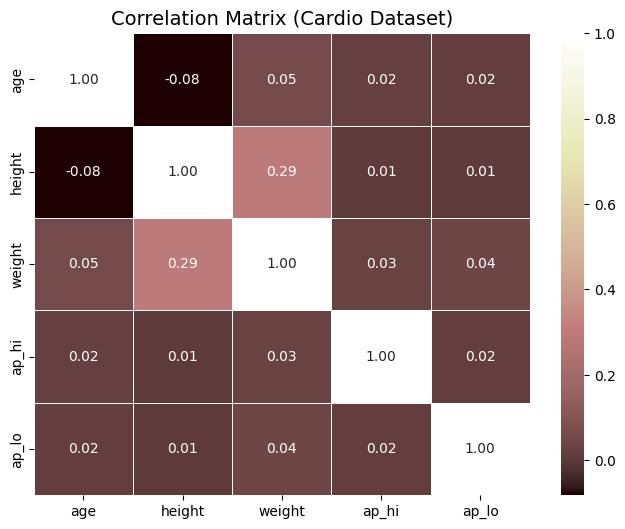

/tmp/ipython-input-2282294969.py:102: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


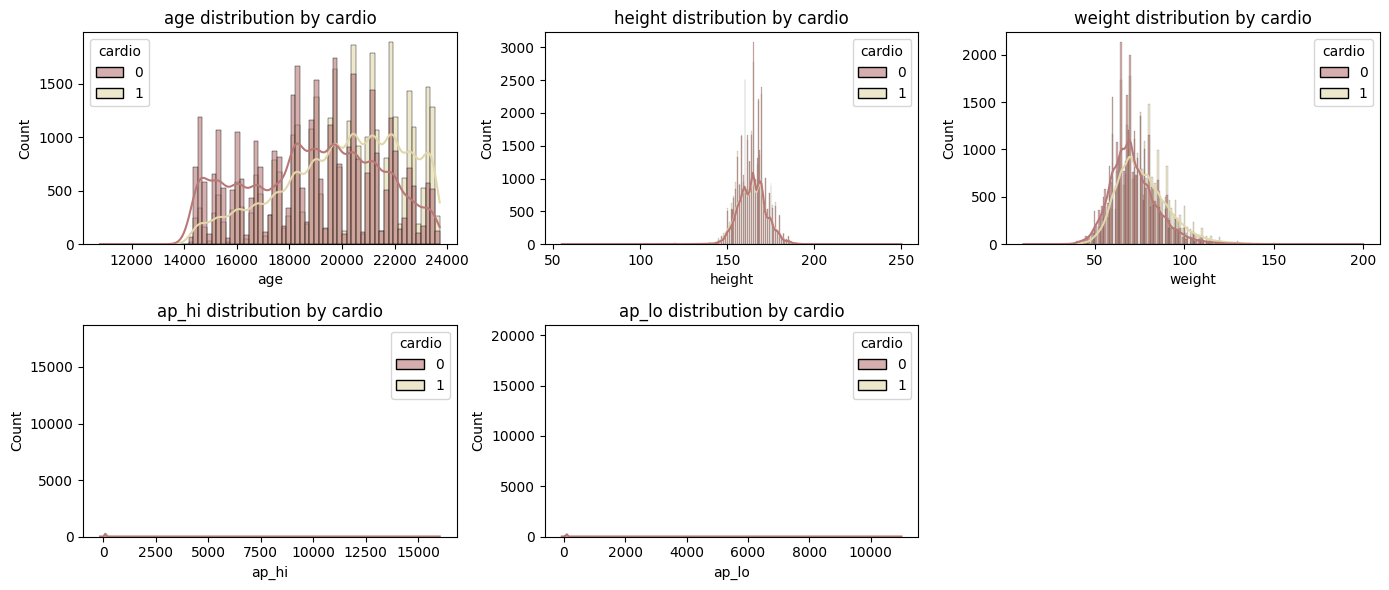

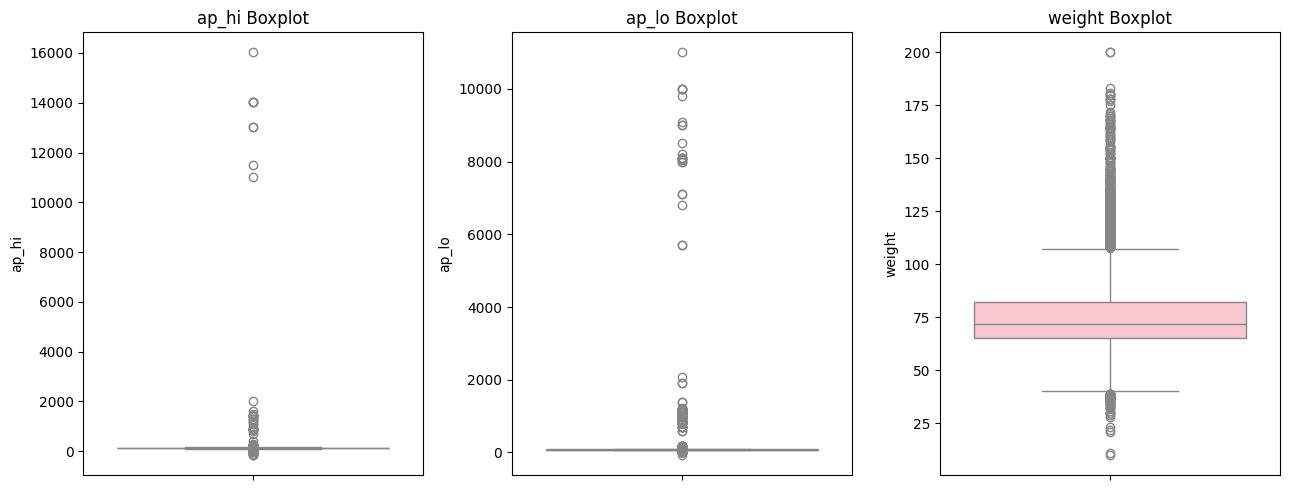

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, isnan, avg, stddev
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# Spark session
# ------------------------------
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("CardioGBT") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# ------------------------------
# Load dataset
# ------------------------------
cardio = spark.read.csv(
    "cardio_train.csv",
    header=True,
    inferSchema=True,
    sep=";"
)

# ------------------------------
# Basic info
# ------------------------------
def basic_info(df):
    print("===== Cardio Dataset =====")
    print("Number of rows:", df.count())
    print("Number of columns:", len(df.columns))
    df.printSchema()
    df.show(5)

basic_info(cardio)

# ------------------------------
# Missing values
# ------------------------------
def missing_values(df):
    print("\nMissing values per column:")
    df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns]).show()

missing_values(cardio)

# ------------------------------
# Target distribution
# ------------------------------
print("\nTarget (cardio) distribution:")
cardio.groupBy("cardio").count().show()

# ------------------------------
# Descriptive stats
# ------------------------------
numeric_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]

print("\nDescriptive statistics:")
cardio.select(
    [avg(c).alias(f"{c}_mean") for c in numeric_cols] +
    [stddev(c).alias(f"{c}_std") for c in numeric_cols]
).show()

# ------------------------------
# Correlation matrix
# ------------------------------
assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="features"
)

cardio_vec = assembler.transform(cardio).select("features")
corr_matrix = Correlation.corr(cardio_vec, "features", "pearson").head()[0]  # DenseMatrix
corr_array = corr_matrix.toArray()

# Convert to Pandas DataFrame
corr_df = pd.DataFrame(corr_array, columns=numeric_cols, index=numeric_cols)

# Plot heatmap with baby pink shades
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap="pink", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Cardio Dataset)", fontsize=14)
plt.show()

# ------------------------------
# Distribution plots
# ------------------------------
cardio_pd = cardio.select(numeric_cols + ["cardio"]).toPandas()

plt.figure(figsize=(14,6))
for i, col_name in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(data=cardio_pd, x=col_name, hue="cardio", kde=True, palette="pink", alpha=0.6)
    plt.title(f"{col_name} distribution by cardio")
plt.tight_layout()
plt.show()

# ------------------------------
# Boxplots for outliers
# ------------------------------
plt.figure(figsize=(13,5))
for i, col_name in enumerate(["ap_hi", "ap_lo", "weight"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=cardio_pd[col_name], color="pink")
    plt.title(f"{col_name} Boxplot")
plt.tight_layout()
plt.show()


# **Data Preparation**

In [3]:
from pyspark.sql.functions import col, when, floor
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml import Pipeline

# ======================================================
# AGE
# ======================================================
cardio = cardio.withColumn("age_years", floor(col("age") / 365))

# ======================================================
# OUTLIERS
# ======================================================
cardio = cardio.filter(
    (col("ap_hi").between(70, 250)) &
    (col("ap_lo").between(40, 200)) &
    (col("weight").between(30, 200)) &
    (col("height").between(120, 220))
)

# ======================================================
# FIX BP
# ======================================================
cardio = cardio.withColumn(
    "ap_hi_fixed",
    when(col("ap_hi") < col("ap_lo"), col("ap_lo")).otherwise(col("ap_hi"))
).withColumn(
    "ap_lo_fixed",
    when(col("ap_lo") > col("ap_hi"), col("ap_hi")).otherwise(col("ap_lo"))
).drop("ap_hi", "ap_lo") \
 .withColumnRenamed("ap_hi_fixed", "ap_hi") \
 .withColumnRenamed("ap_lo_fixed", "ap_lo")

# ======================================================
# CAST CATEGORICAL
# ======================================================
for c in ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]:
    cardio = cardio.withColumn(c, col(c).cast("int"))

# ======================================================
# FEATURE ENGINEERING
# ======================================================
cardio = cardio.withColumn("BMI", col("weight") / ((col("height") / 100) ** 2))
cardio = cardio.withColumn("pulse_pressure", col("ap_hi") - col("ap_lo"))
cardio = cardio.withColumn("map", col("ap_lo") + col("pulse_pressure") / 3)

cardio = cardio.withColumn(
    "hypertension",
    when((col("ap_hi") >= 140) | (col("ap_lo") >= 90), 1).otherwise(0)
)

cardio = cardio.withColumn(
    "bp_stage",
    when((col("ap_hi") < 120) & (col("ap_lo") < 80), 0)
    .when((col("ap_hi") < 140) & (col("ap_lo") < 90), 1)
    .when((col("ap_hi") < 160) & (col("ap_lo") < 100), 2)
    .otherwise(3)
)

cardio = cardio.withColumn(
    "bmi_class",
    when(col("BMI") < 18.5, 0)
    .when(col("BMI") < 25, 1)
    .when(col("BMI") < 30, 2)
    .otherwise(3)
)

cardio = cardio.withColumn(
    "metabolic_risk",
    (col("cholesterol") > 1).cast("int") +
    (col("gluc") > 1).cast("int") +
    (col("BMI") > 30).cast("int")
)

cardio = cardio.withColumn(
    "lifestyle_risk",
    col("smoke") + col("alco") + (1 - col("active"))
)

# ======================================================
# AGE GROUP (STRING ONLY — INDEXED IN PIPELINE)
# ======================================================
cardio = cardio.withColumn(
    "age_group",
    when(col("age_years") < 30, "under_30")
    .when(col("age_years") < 40, "30_39")
    .when(col("age_years") < 50, "40_49")
    .when(col("age_years") < 60, "50_59")
    .otherwise("60_plus")
)

# ======================================================
# PIPELINE (INDEX → ASSEMBLE → SCALE)
# ======================================================
age_indexer = StringIndexer(
    inputCol="age_group",
    outputCol="age_group_idx"
)

numeric_cols = [
    "age_years", "height", "weight",
    "ap_hi", "ap_lo",
    "BMI", "pulse_pressure", "map",
    "metabolic_risk", "lifestyle_risk"
]

categorical_cols = [
    "gender", "cholesterol", "gluc",
    "smoke", "alco", "active",
    "hypertension", "bp_stage", "bmi_class"
]

assembler = VectorAssembler(
    inputCols=numeric_cols + categorical_cols + ["age_group_idx"],
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

pipeline = Pipeline(stages=[
    age_indexer,
    assembler,
    scaler
])

cardio = pipeline.fit(cardio).transform(cardio)

# ======================================================
# READY
# ======================================================
cardio.select("features", "cardio").show(5, truncate=False)


+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|features                                                                                                                                                                                                                                                                                                                                                                                                       |cardio|
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# **Visualize the newly created features**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


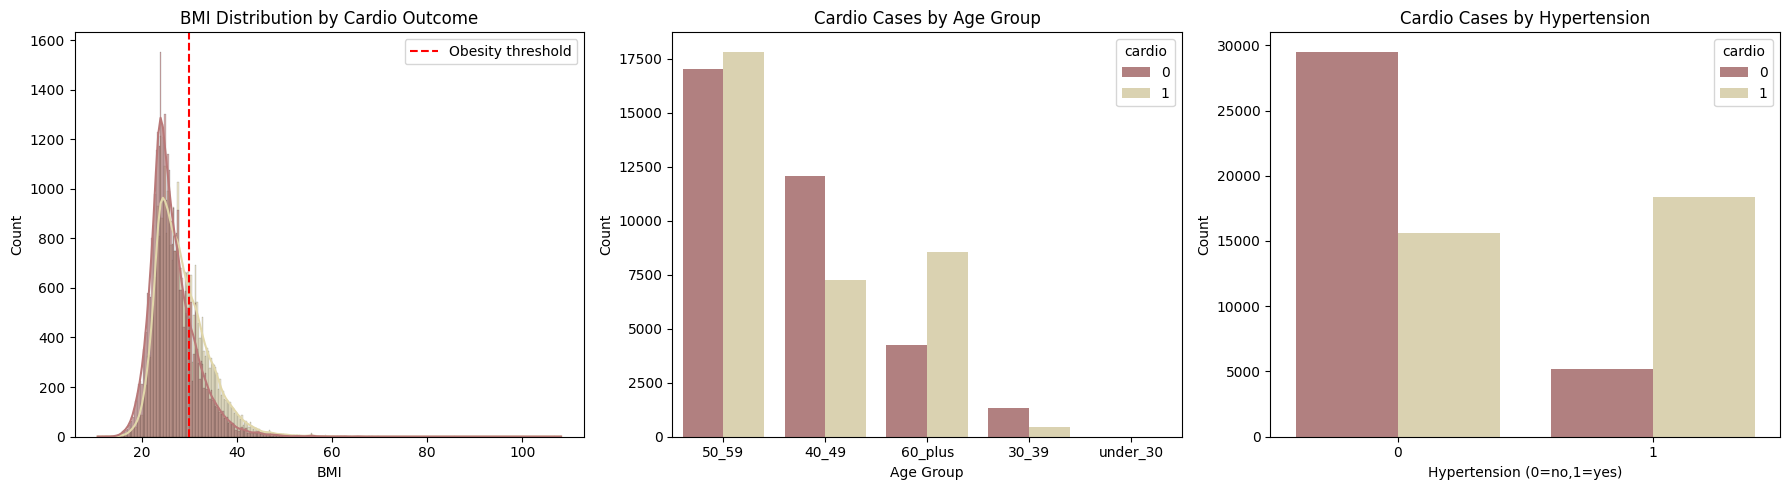

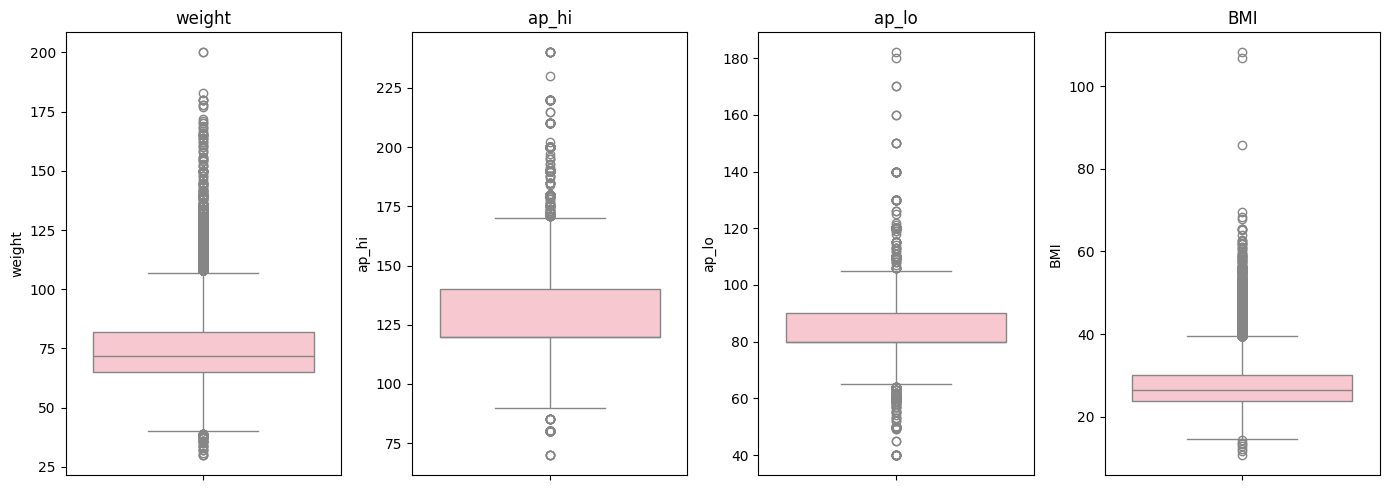

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
cardio_pd = cardio.select("BMI", "cardio", "age_group", "hypertension").toPandas()

# Create 3 subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# BMI distribution
sns.histplot(cardio_pd, x="BMI", hue="cardio", kde=True, palette="pink", alpha=0.6, ax=axes[0])
axes[0].axvline(30, color='red', linestyle='--', label='Obesity threshold')
axes[0].set_title("BMI Distribution by Cardio Outcome")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Count")
axes[0].legend()

# Age group counts
sns.countplot(data=cardio_pd, x="age_group", hue="cardio", palette="pink", ax=axes[1])
axes[1].set_title("Cardio Cases by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")

# Hypertension counts
sns.countplot(data=cardio_pd, x="hypertension", hue="cardio", palette="pink", ax=axes[2])
axes[2].set_title("Cardio Cases by Hypertension")
axes[2].set_xlabel("Hypertension (0=no,1=yes)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

# ------------------------------
# Boxplots for numeric features (separate)
# ------------------------------
cardio_pd_box = cardio.select("weight", "ap_hi", "ap_lo", "BMI").toPandas()

plt.figure(figsize=(14,5))
for i, col_name in enumerate(["weight", "ap_hi", "ap_lo", "BMI"]):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=cardio_pd_box[col_name], color="pink")
    plt.title(col_name)
plt.tight_layout()
plt.show()


# Logistic Regression

In [6]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

lr = LogisticRegression(
    featuresCol="features",
    labelCol="cardio",
    maxIter=100
)

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

evaluator = BinaryClassificationEvaluator(
    labelCol="cardio",
    metricName="areaUnderROC"
)

cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

train_df, test_df = cardio.randomSplit([0.7, 0.3], seed=42)

lr_model = cv.fit(train_df)
lr_preds = lr_model.transform(test_df)

print("Logistic Regression AUC:",
      evaluator.evaluate(lr_preds))


Logistic Regression AUC: 0.7954940042849002


# Random Forest (Spark)

In [7]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="cardio",
    numTrees=300,
    maxDepth=12
)

rf_model = rf.fit(train_df)
rf_preds = rf_model.transform(test_df)

print("Random Forest AUC:",
      evaluator.evaluate(rf_preds))


Random Forest AUC: 0.8007839573700164


# Gradient Boosted Trees (Spark alternative to XGBoost)

In [8]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="cardio",
    maxIter=50,
    maxDepth=3,
    stepSize=0.1,
    subsamplingRate=0.8
)

train_df = train_df.cache()
test_df = test_df.cache()

train_df.count()  # materialize


gbt_model = gbt.fit(train_df)
gbt_preds = gbt_model.transform(test_df)

print("GBT AUC:",
      evaluator.evaluate(gbt_preds))


GBT AUC: 0.8014820582900243


# **Visualization**

In [11]:
plot_df = gbt_preds.select("probability", "cardio").toPandas()
display(plot_df.head())


,probability,cardio
0,"[0.20970372649126662, 0.7902962735087333]",1
1,"[0.20533643020884973, 0.7946635697911503]",0
2,"[0.7839670009511217, 0.2160329990488783]",0
3,"[0.7467647088912581, 0.2532352911087419]",0
4,"[0.7595078366770438, 0.2404921633229562]",0


In [12]:
plot_df.shape


(20720, 2)

In [17]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="cardio",
    predictionCol="prediction",
    metricName="accuracy"
)
lr_accuracy = accuracy_evaluator.evaluate(lr_preds)
print("Logistic Regression Accuracy:", lr_accuracy)

rf_accuracy = accuracy_evaluator.evaluate(rf_preds)
print("Random Forest Accuracy:", rf_accuracy)

gbt_accuracy = accuracy_evaluator.evaluate(gbt_preds)
print("GBT Accuracy:", gbt_accuracy)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosted Trees"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gbt_accuracy
    ]
})
results.sort_values(by="Accuracy", ascending=False)

Logistic Regression Accuracy: 0.733976833976834
Random Forest Accuracy: 0.7377895752895753
GBT Accuracy: 0.7358590733590734


,Model,Accuracy
1,Random Forest,0.737790
2,Gradient Boosted Trees,0.735859
0,Logistic Regression,0.733977


/tmp/ipython-input-178851710.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


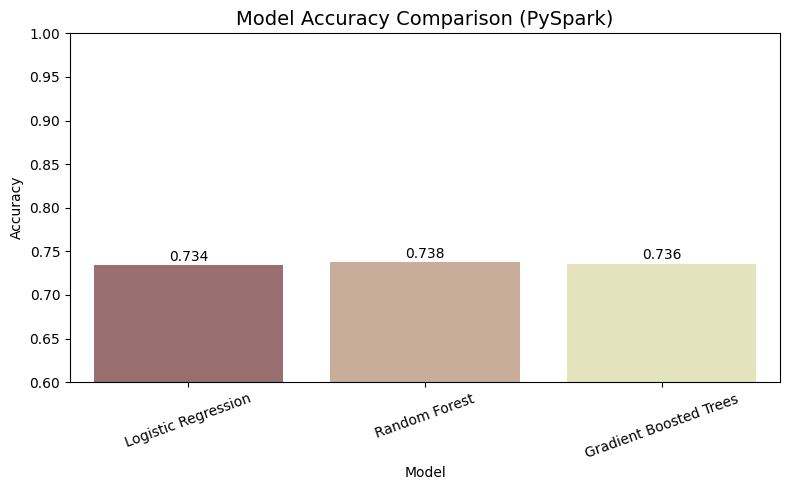

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="pink"
)

plt.ylim(0.6, 1)
plt.title("Model Accuracy Comparison (PySpark)", fontsize=14)
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

# Add values on bars
for index, row in results.iterrows():
    plt.text(
        index,
        row["Accuracy"] + 0.005,
        f"{row['Accuracy']:.3f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()
